# Logistic Regression for Diabetes Prediction

## 1. Data Exploration

### Objective

The objective of this project is to explore the diabetes dataset and build a Logistic Regression model to predict whether a person has diabetes.

The target variable is `Outcome`:

- `0` = No diabetes
- `1` = Diabetes

The dataset contains medical and demographic features such as Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age.

### 1(a) Loading the Dataset

First, we import the required libraries and load the diabetes dataset using Pandas.

In [1]:
# Import required library
import pandas as pd

# Load the dataset
df = pd.read_csv("diabetes.csv")

# Display the first five rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Display the number of rows and columns
print("Shape of the dataset:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns)

# Display data types and non-null information
print("\nDataset information:")
df.info()

Shape of the dataset: (768, 9)

Column names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
# Check the number of missing values in each column
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

### Summary Statistics

The `describe()` function provides statistical information such as count, mean, standard deviation, minimum, maximum, and quartile values for the numerical features.

In [5]:
# Display summary statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# Count observations in each target class
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [10]:
# Display target class percentages
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

### 1(c) Histograms

Histograms are used to understand the distribution of numerical features. They help identify the center, spread, skewness, and possible unusual values in the data.

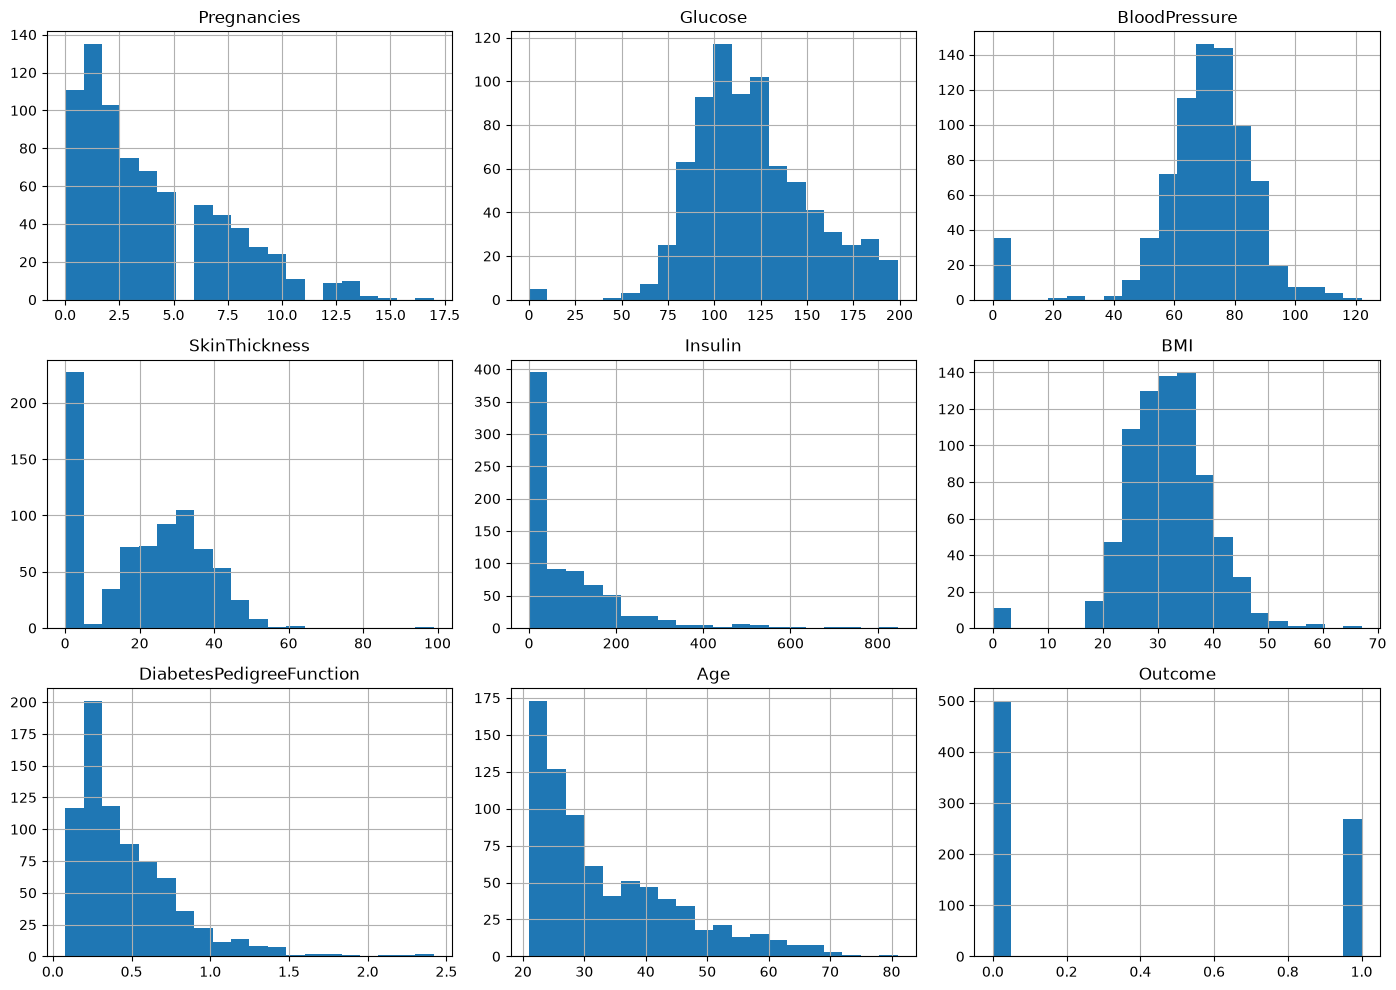

In [11]:
# Import matplotlib
import matplotlib.pyplot as plt

# Create histograms for all numerical columns
df.hist(figsize=(14, 10), bins=20)

# Adjust the layout
plt.tight_layout()

# Display the plots
plt.show()

### Box Plots

Box plots are used to visualize the distribution of numerical features and identify possible outliers.

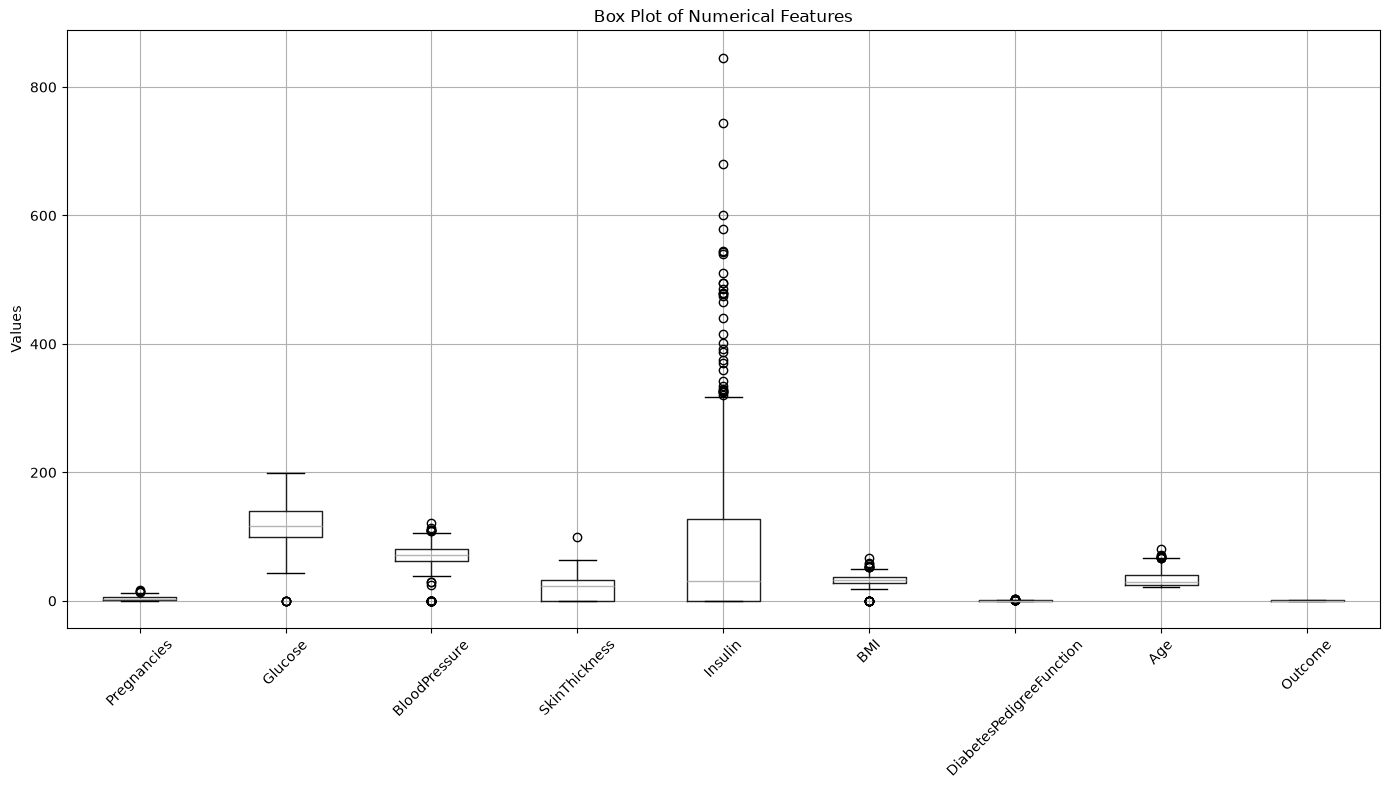

In [12]:
plt.figure(figsize=(14, 8))

df.boxplot()

plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Features")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

### Correlation Analysis

Correlation analysis is used to examine the relationship between numerical features and the target variable.

A correlation value close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship. A value close to 0 indicates a weak linear relationship.

In [13]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


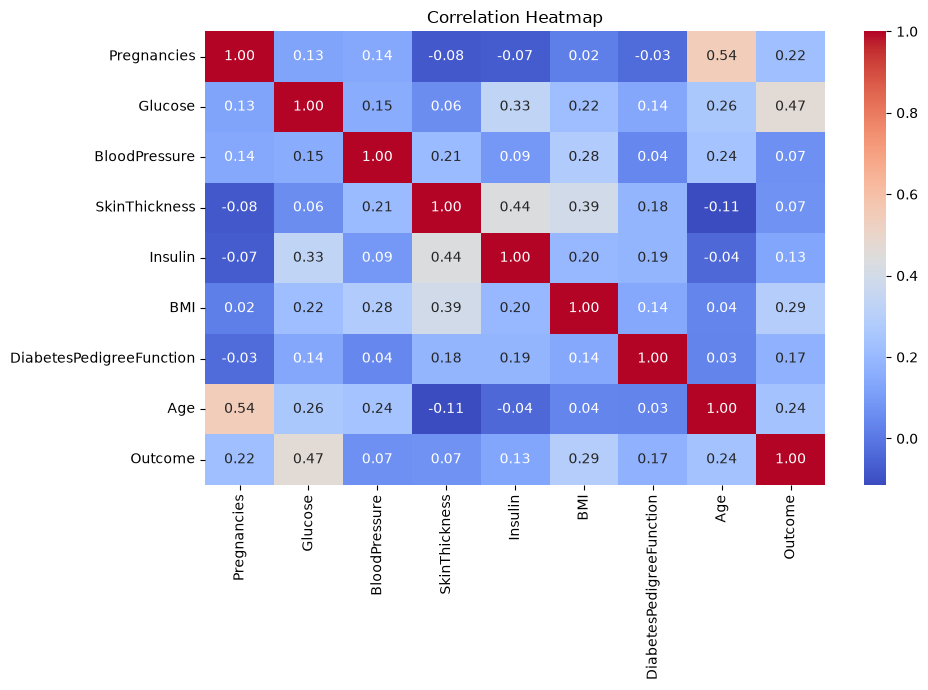

In [14]:
# Import seaborn for the heatmap
import seaborn as sns

# Create correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Pair Plot

A pair plot is used to visualize relationships between multiple numerical features. It also shows the distribution of individual features and helps identify patterns between the features and the target classes.

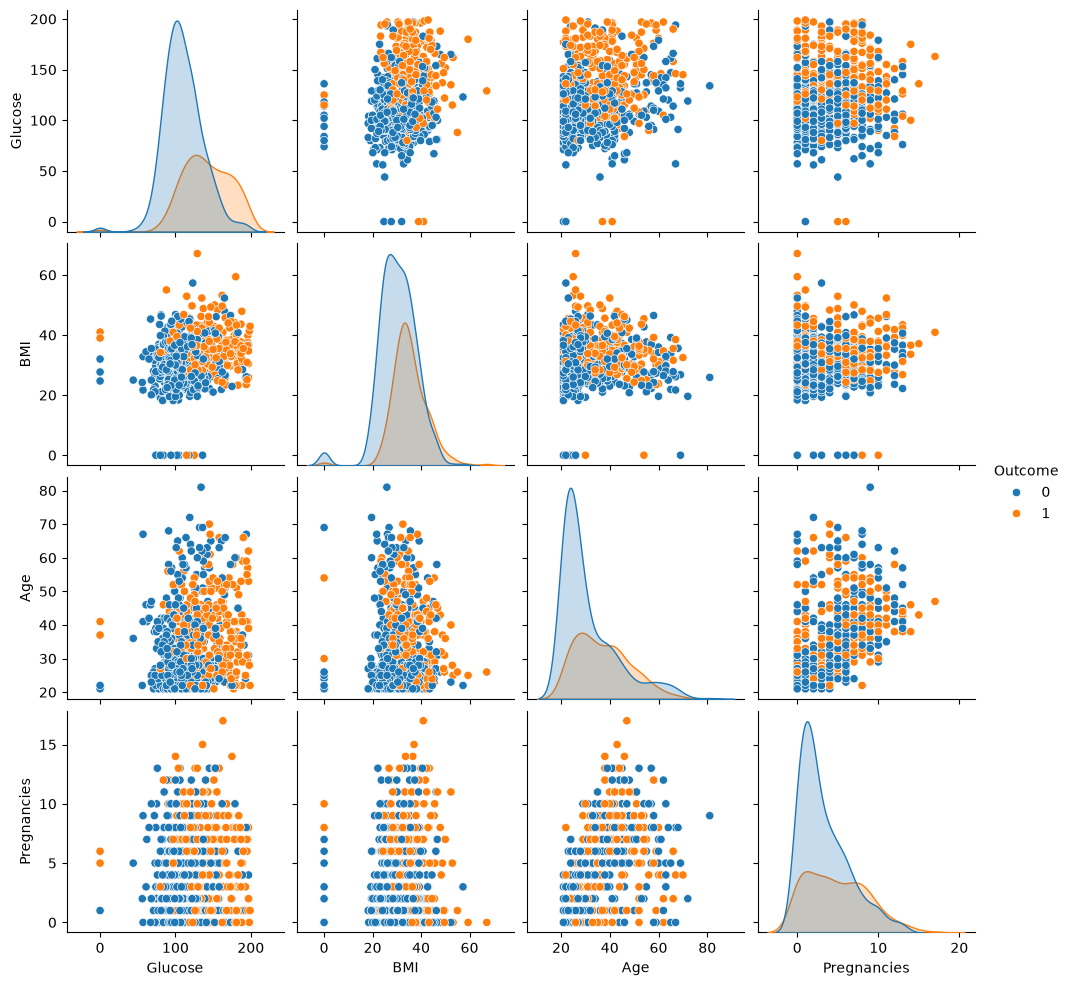

In [15]:
# Create a pair plot for selected important features
sns.pairplot(
    df[[
        "Glucose",
        "BMI",
        "Age",
        "Pregnancies",
        "Outcome"
    ]],
    hue="Outcome"
)

plt.show()

### Analysis of Patterns and Correlations

- The histograms show the distribution of the numerical features.
- The box plots show the presence of possible outliers in some features.
- The correlation heatmap shows the relationships between the features.
- Glucose has a noticeable relationship with the `Outcome` variable.
- The pair plot helps visualize relationships between selected features for the two outcome classes.

## 2. Data Preprocessing

Data preprocessing is performed to prepare the dataset for Logistic Regression.

The preprocessing steps include handling invalid or missing values and checking categorical variables before building the model.

In [17]:
import numpy as np

# Columns where zero is considered an invalid/missing value
missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace zero values with NaN
df[missing_columns] = df[missing_columns].replace(0, np.nan)

# Check missing values
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [18]:
# Fill missing values with the median of each column
for column in missing_columns:
    df[column] = df[column].fillna(df[column].median())

# Check again for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### 2(b) Encoding Categorical Variables

The dataset contains numerical predictor variables only. Therefore, there are no categorical variables that require encoding.

The target variable `Outcome` is already represented numerically:

- `0` = No diabetes
- `1` = Diabetes

Therefore, no categorical encoding is required for this dataset.`m

In [19]:
# Display the data types
df.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

### Separating Features and Target

The predictor variables are stored in `X`, while the target variable `Outcome` is stored in `y`.

- `X` contains the features used to predict diabetes.
- `y` contains the diabetes outcome.

In [20]:
# Separate features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Display the shape of X and y
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


### Splitting the Dataset

The dataset is divided into training and testing sets.

The training data is used to train the Logistic Regression model, while the testing data is used to evaluate its performance on unseen data.

In [21]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


In [22]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


## 3. Model Building

Logistic Regression is a classification algorithm used to predict a binary target variable.

In this project, the model is used to predict whether a person has diabetes:

- `0` = No diabetes
- `1` = Diabetes

Before training the model, the numerical features are standardized so that they are on a similar scale.

### Feature Scaling

The features have different ranges. For example, `Age`, `Glucose`, and `Insulin` have different numerical scales.

StandardScaler is used to standardize the features before training the Logistic Regression model.

In [24]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [25]:
scaler.fit_transform(X_train)

array([[-0.85135507, -1.05642747, -0.82674004, ..., -0.76947697,
         0.31079384, -0.79216928],
       [ 0.35657564,  0.14439907,  0.47777235, ..., -0.41749769,
        -0.11643851,  0.56103382],
       [-0.5493724 , -0.55608308, -1.15286813, ...,  0.3597899 ,
        -0.76486207, -0.70759409],
       ...,
       [-0.85135507, -0.82293342, -0.17448384, ...,  0.82909561,
        -0.78607218, -0.28471812],
       [ 1.86648903, -0.35594533, -0.17448384, ..., -0.72547956,
        -1.01938346,  0.56103382],
       [ 0.05459296,  0.74481233, -1.15286813, ..., -0.43216349,
        -0.57700104,  0.30730824]], shape=(614, 8))

In [26]:
scaler.transform(X_test)

array([[ 0.96054099,  1.24515673, -0.66367599, ..., -0.74014536,
        -0.55579092,  0.56103382],
       [ 1.86648903, -1.79026591,  2.76066903, ...,  0.44778472,
        -0.58306107,  1.15306018],
       [-0.5493724 ,  0.01097389,  0.3147083 , ...,  0.50644793,
         0.01688223, -0.6230189 ],
       ...,
       [-0.5493724 , -1.32327781, -1.64206028, ..., -0.57882152,
         3.70138246, -0.70759409],
       [ 0.05459296,  2.07906404,  0.47777235, ...,  0.66777177,
        -0.64669142, -0.20014293],
       [-0.85135507, -1.69019703,  0.47777235, ...,  0.11047124,
        -0.16794879, -1.04589487]], shape=(154, 8))

### 3(a) Building the Logistic Regression Model

A Logistic Regression model is created using Scikit-learn. The model will learn the relationship between the input features and the binary `Outcome` target.

In [27]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(random_state=42)

### 3(b) Training the Model

The Logistic Regression model is trained using the scaled training data and the corresponding target values.

In [28]:
# Train the Logistic Regression model
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Making Predictions

After training the model, predictions are made on the testing data.

The model also provides prediction probabilities, which will be used later to calculate the ROC-AUC score and plot the ROC curve.

In [29]:
# Predict the class labels
y_pred = model.predict(X_test_scaled)

# Predict the probability of diabetes
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Display the first 10 predictions
print("Predicted classes:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

Predicted classes: [1 0 0 0 0 0 0 1 0 1]
Predicted probabilities: [0.60971073 0.11835576 0.29346313 0.2508367  0.03320667 0.16852385
 0.4881643  0.92367511 0.08143405 0.8385896 ]


## 4. Model Evaluation

The performance of the Logistic Regression model is evaluated using the testing data.

The following evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC score

The ROC curve is also plotted to visualize the classification performance of the model.

### Evaluation Metrics

The model predictions are compared with the actual target values from the testing dataset.

Accuracy measures the overall proportion of correct predictions.

Precision measures how many of the observations predicted as diabetes are actually diabetes cases.

Recall measures how many of the actual diabetes cases are correctly identified.

F1-score is the harmonic mean of precision and recall.

ROC-AUC measures the model's ability to distinguish between the two classes across different classification thresholds.

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display the results
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1-Score : 0.5454545454545454
ROC-AUC  : 0.812962962962963


In [31]:
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc * 100:.2f}%")

Accuracy : 70.78%
Precision: 60.00%
Recall   : 50.00%
F1-Score : 54.55%
ROC-AUC  : 81.30%


### ROC Curve

The Receiver Operating Characteristic (ROC) curve shows the relationship between the True Positive Rate and False Positive Rate at different classification thresholds.

The Area Under the Curve (AUC) summarizes the overall ability of the model to distinguish between the two classes.

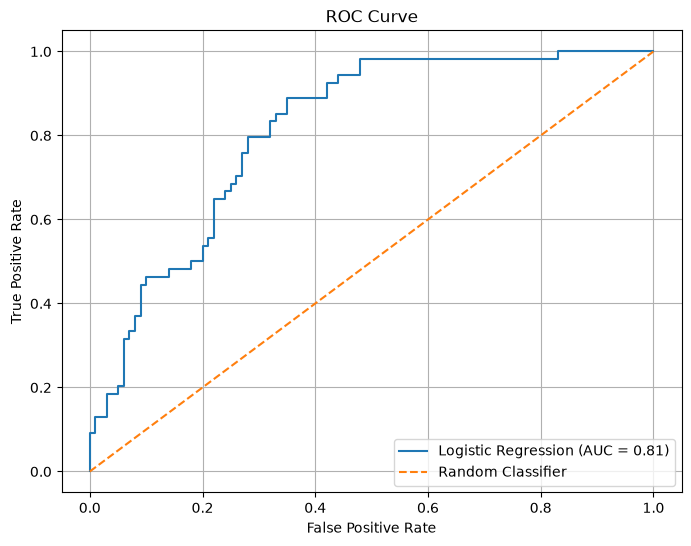

In [32]:
from sklearn.metrics import roc_curve

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

# Plot random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

## 5. Interpretation

### 5(a) Interpretation of Logistic Regression Coefficients

Logistic Regression assigns a coefficient to each feature.

A positive coefficient indicates that an increase in the feature is associated with an increase in the log-odds of the positive class, which is diabetes (`Outcome = 1`).

A negative coefficient indicates that an increase in the feature is associated with a decrease in the log-odds of diabetes.

Since the features were standardized before training, the coefficients can be compared based on their relative magnitude.

In [33]:
# Create a DataFrame containing feature names and model coefficients
coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Sort coefficients by their value
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df

,Feature,Coefficient
1,Glucose,1.182511
5,BMI,0.688735
0,Pregnancies,0.377502
6,DiabetesPedigreeFunction,0.233386
7,Age,0.147798
3,SkinThickness,0.028225
2,BloodPressure,-0.044066
4,Insulin,-0.066157


### Logistic Regression Coefficients

The coefficient plot shows the direction and relative strength of the relationship between each standardized feature and the predicted probability of diabetes.

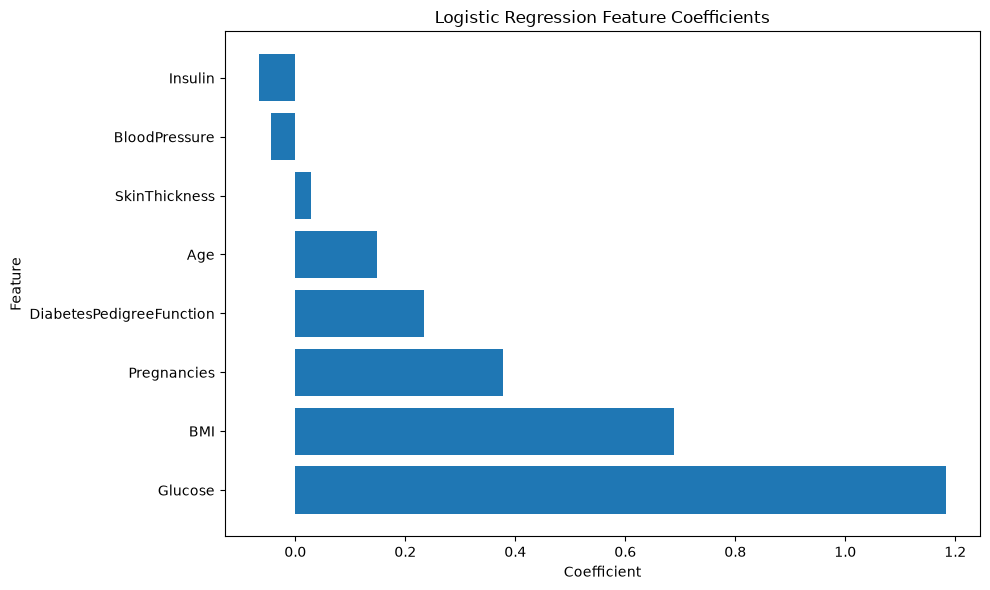

In [34]:
# Plot Logistic Regression coefficients
plt.figure(figsize=(10, 6))

plt.barh(
    coefficient_df["Feature"],
    coefficient_df["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")

plt.tight_layout()
plt.show()

### 5(b) Feature Significance

The coefficients are used to understand how the features contribute to diabetes prediction.

Features with positive coefficients are associated with higher predicted log-odds of diabetes, while features with negative coefficients are associated with lower predicted log-odds of diabetes.

The magnitude of the standardized coefficient indicates the relative strength of the feature's contribution to the model.

Therefore, the features with larger absolute coefficient values have a greater influence on the Logistic Regression model compared with features having smaller absolute coefficient values.

In [35]:
# Sort features by absolute coefficient value
coefficient_df["Absolute_Coefficient"] = coefficient_df["Coefficient"].abs()

coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

,Feature,Coefficient,Absolute_Coefficient
1,Glucose,1.182511,1.182511
5,BMI,0.688735,0.688735
0,Pregnancies,0.377502,0.377502
6,DiabetesPedigreeFunction,0.233386,0.233386
7,Age,0.147798,0.147798
4,Insulin,-0.066157,0.066157
2,BloodPressure,-0.044066,0.044066
3,SkinThickness,0.028225,0.028225


## 6. Deployment with Streamlit

The trained Logistic Regression model is deployed using Streamlit.

The Streamlit application allows users to enter the required medical features and receive a diabetes prediction from the trained model.

### Saving the Trained Model and Scaler

The trained Logistic Regression model and StandardScaler are saved using Joblib.

The saved files will be loaded by the Streamlit application to make predictions on new user inputs.

In [36]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(model, "logistic_regression_model.pkl")

# Save the StandardScaler
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


# Interview Questions

## 1. What is the difference between precision and recall?

Precision measures how many of the observations predicted as positive are actually positive.

Recall measures how many of the actual positive observations are correctly identified by the model.

Precision focuses on the correctness of positive predictions, while recall focuses on identifying as many actual positive cases as possible.

## 2. What is cross-validation, and why is it important in binary classification?

Cross-validation is a technique used to evaluate the performance and generalization ability of a machine learning model.

In cross-validation, the dataset is divided into multiple parts called folds. The model is trained and evaluated multiple times using different combinations of training and validation data.

For binary classification, cross-validation is important because it helps check whether the model performs consistently on different subsets of the data and reduces dependence on a single train-test split.